# Task W1-06 -- Week 1 종합 리포트 + Go/No-Go 결정

**Feature ID**: REPORT-001
**Sub-plan**: `docs/stage1-subplans/w1-06-week1-report.md`

Week 1 전체 결과(W1-01 ~ W1-05)를 통합하여 사전 지정 Go 기준 5개를 자동 평가하고,
Go/No-Go 의사결정을 위한 리포트와 시나리오 옵션을 생성한다.

## 핵심 원칙

> **사전 지정 파라미터 결과만 평가한다.**
> 민감도 그리드에서 "최고값"을 선택하는 data snooping은 절대 금지.
> 4시간봉(W1-05) 결과는 참고용이며 Go/No-Go 기준이 아니다.
> 프로젝트 목표: **안정적인 수익 구조** -- 단기 PASS가 아니라 검증된 엣지.

## Go 기준 (사전 지정, 모두 충족 시 Go)

1. Strategy A 일봉 Sharpe > 0.8
2. Strategy B 일봉 Sharpe > 0.5
3. 두 전략 중 하나라도 MDD < 50%
4. 두 전략 중 하나라도 5개 연도 중 최소 2개 양수 수익
5. 사전 지정 파라미터가 민감도 평탄 영역


In [1]:
import pandas as pd
import numpy as np
import vectorbt as vbt
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ta.momentum import RSIIndicator

from importlib.metadata import version
print(f"pandas:     {version('pandas')}")
print(f"numpy:      {version('numpy')}")
print(f"vectorbt:   {version('vectorbt')}")
print(f"matplotlib: {version('matplotlib')}")
print(f"ta:         {version('ta')}")


pandas:     2.3.3
numpy:      2.3.5
vectorbt:   0.28.5
matplotlib: 3.10.8
ta:         0.11.0


In [2]:
OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

PARQUET_1D = 'KRW-BTC_1d_frozen_20260412.parquet'
PARQUET_4H = 'KRW-BTC_4h_frozen_20260412.parquet'

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

# 데이터 해시 재검증 (W1-01 일관성)
with open(DATA_DIR / 'data_hashes.txt') as f:
    expected_hashes = {}
    for line in f:
        line = line.strip()
        if line and not line.startswith('#') and ':' in line:
            k, v = line.split(': ', 1)
            expected_hashes[k] = v

hash_1d = sha256_file(DATA_DIR / PARQUET_1D)
hash_4h = sha256_file(DATA_DIR / PARQUET_4H)
assert hash_1d == expected_hashes[PARQUET_1D], "1d hash mismatch!"
assert hash_4h == expected_hashes[PARQUET_4H], "4h hash mismatch!"
print(f"Data hashes verified (1d, 4h)")

# JSON 로드
with open(OUT_DIR / 'strategy_a_daily.json') as f:
    result_a = json.load(f)
with open(OUT_DIR / 'strategy_b_daily.json') as f:
    result_b = json.load(f)
with open(OUT_DIR / 'robustness_sensitivity.json') as f:
    result_robust = json.load(f)
with open(OUT_DIR / 'strategy_4h_comparison.json') as f:
    result_4h = json.load(f)

# 모든 JSON 동일 data hash 참조 확인
assert result_a['data_hash'] == hash_1d
assert result_b['data_hash'] == hash_1d
assert result_robust['data_hash'] == hash_1d
assert result_4h['data']['1d']['hash'] == hash_1d
assert result_4h['data']['4h']['hash'] == hash_4h
print(f"All W1-0* JSONs reference identical frozen data hash (1d/4h)")
print(f"  1d hash: {hash_1d[:16]}...")
print(f"  4h hash: {hash_4h[:16]}...")


Data hashes verified (1d, 4h)
All W1-0* JSONs reference identical frozen data hash (1d/4h)
  1d hash: da5b5a5bd74c1be0...
  4h hash: 0b43e3b86da8534c...


In [3]:
# === W1-01 데이터 요약 ===
data_1d_info = {
    'file': result_a['data_file'],
    'bars': result_a['data_bars'],
    'range': result_a['data_range'],
    'hash': result_a['data_hash'],
}
data_4h_info = result_4h['data']['4h']

print("=" * 70)
print("W1-01 데이터 수집 결과")
print("=" * 70)
print(f"기간: {data_1d_info['range'][0]} ~ {data_1d_info['range'][1]}")
print(f"일봉: {data_1d_info['bars']} bars")
print(f"4시간봉: {data_4h_info['bars']} bars")
print(f"데이터 해시 (1d): {data_1d_info['hash'][:32]}...")
print(f"데이터 해시 (4h): {data_4h_info['hash'][:32]}...")


W1-01 데이터 수집 결과
기간: 2021-01-01T00:00:00+00:00 ~ 2026-04-11T00:00:00+00:00
일봉: 1927 bars
4시간봉: 11561 bars
데이터 해시 (1d): da5b5a5bd74c1be06b6c363f71e0f740...
데이터 해시 (4h): 0b43e3b86da8534c994beff2e784656f...


In [4]:
# === W1-02 Strategy A 일봉 요약 ===
m_a = result_a['metrics']
p_a = result_a['parameters']

print("=" * 70)
print("W1-02 Strategy A 일봉 (추세 추종) -- 사전 지정 파라미터")
print("=" * 70)
print(f"파라미터: MA={p_a['ma_period']}, Donchian={p_a['donchian_high']}/{p_a['donchian_low']}, "
      f"Vol>{p_a['vol_mult']}x, SL={p_a['sl_pct']*100:.0f}%")
print(f"")
print(f"Sharpe:          {m_a['sharpe']:.4f}  (Go 기준 > 0.8)")
print(f"  95% CI (Lo):   [{m_a['sharpe_ci_95_normal'][0]:.4f}, {m_a['sharpe_ci_95_normal'][1]:.4f}]")
print(f"Total Return:    {m_a['total_return']*100:.2f}%")
print(f"Max Drawdown:    {m_a['max_drawdown']*100:.2f}%  (Go 기준 < 50%)")
print(f"Deepest DD:")
print(f"  pct:           {m_a['deepest_drawdown']['pct']*100:.2f}%")
print(f"  duration:      {m_a['deepest_drawdown']['duration_days']}일")
print(f"  status:        {m_a['deepest_drawdown']['status']}")
print(f"  peak:          {m_a['deepest_drawdown']['peak_timestamp']}")
print(f"Trades:          {m_a['total_trades']}")
print(f"Win Rate:        {m_a['win_rate']*100:.2f}%")
print(f"Profit Factor:   {m_a['profit_factor']:.4f}")


W1-02 Strategy A 일봉 (추세 추종) -- 사전 지정 파라미터
파라미터: MA=200, Donchian=20/10, Vol>1.5x, SL=8%

Sharpe:          1.0353  (Go 기준 > 0.8)
  95% CI (Lo):   [0.9799, 1.0906]
Total Return:    171.76%
Max Drawdown:    -22.45%  (Go 기준 < 50%)
Deepest DD:
  pct:           -22.45%
  duration:      480일
  status:        Active
  peak:          2024-12-17T00:00:00+00:00
Trades:          14
Win Rate:        50.00%
Profit Factor:   2.9562


In [5]:
# === W1-03 Strategy B 일봉 요약 ===
m_b = result_b['metrics']
p_b = result_b['parameters']

print("=" * 70)
print("W1-03 Strategy B 일봉 (평균 회귀) -- 사전 지정 파라미터")
print("=" * 70)
print(f"파라미터: MA={p_b['ma_period']}, RSI({p_b['rsi_period']})<{p_b['rsi_buy']} entry, "
      f"RSI>{p_b['rsi_sell']} exit, TimeStop={p_b['time_stop_days']}d, SL={p_b['sl_pct']*100:.0f}%")
print(f"")
print(f"Sharpe:          {m_b['sharpe']:.4f}  (Go 기준 > 0.5)")
print(f"  95% CI (Lo):   [{m_b['sharpe_ci_95_normal'][0]:.4f}, {m_b['sharpe_ci_95_normal'][1]:.4f}]")
print(f"Total Return:    {m_b['total_return']*100:.2f}%")
print(f"Max Drawdown:    {m_b['max_drawdown']*100:.2f}%  (Go 기준 < 50%)")
print(f"Deepest DD:")
print(f"  pct:           {m_b['deepest_drawdown']['pct']*100:.2f}%")
print(f"  duration:      {m_b['deepest_drawdown']['duration_days']}일")
print(f"  status:        {m_b['deepest_drawdown']['status']}")
print(f"  peak:          {m_b['deepest_drawdown']['peak_timestamp']}")
print(f"Trades:          {m_b['total_trades']}")
print(f"Win Rate:        {m_b['win_rate']*100:.2f}%")
print(f"Profit Factor:   {m_b['profit_factor']:.4f}")


W1-03 Strategy B 일봉 (평균 회귀) -- 사전 지정 파라미터
파라미터: MA=200, RSI(4)<25 entry, RSI>50 exit, TimeStop=5d, SL=8%

Sharpe:          0.1362  (Go 기준 > 0.5)
  95% CI (Lo):   [0.0913, 0.1810]
Total Return:    4.94%
Max Drawdown:    -21.27%  (Go 기준 < 50%)
Deepest DD:
  pct:           -21.27%
  duration:      715일
  status:        Active
  peak:          2024-04-26T00:00:00+00:00
Trades:          39
Win Rate:        53.85%
Profit Factor:   1.0915


In [6]:
# === Equity curve 생성을 위해 4개 백테스트 재실행 ===
# (JSON의 metric 수치는 원본 그대로 사용, equity 시계열만 새로 생성)

INIT_CASH = 1_000_000
FEES = 0.0005
SLIPPAGE = 0.0005

df_1d = pd.read_parquet(DATA_DIR / PARQUET_1D)
df_4h = pd.read_parquet(DATA_DIR / PARQUET_4H)

def run_a(close, high, low, volume, ma, dh, dl, vol_avg, vol_mult, sl, freq):
    ma_s = close.rolling(ma).mean()
    dh_s = high.rolling(dh).max().shift(1)
    dl_s = low.rolling(dl).min().shift(1)
    va_s = volume.rolling(vol_avg).mean().shift(1)
    entries = ((close > ma_s) & (close > dh_s) & (volume > va_s * vol_mult)).fillna(False).astype(bool)
    exits = (close < dl_s).fillna(False).astype(bool)
    return vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        sl_stop=sl, sl_trail=False,
        init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=freq,
    )

def run_b(close, ma, rsi_p, rsi_buy, rsi_sell, time_stop_bars, sl, freq):
    ma_s = close.rolling(ma).mean()
    rsi = RSIIndicator(close=close, window=rsi_p).rsi()
    entries = ((close > ma_s) & (rsi < rsi_buy)).fillna(False).astype(bool)
    rsi_exits = (rsi > rsi_sell).fillna(False).astype(bool)
    time_exits = entries.shift(time_stop_bars).fillna(False).astype(bool)
    exits = (rsi_exits | time_exits).astype(bool)
    return vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        sl_stop=sl, sl_trail=False,
        init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=freq,
    )

pf_a_1d = run_a(df_1d['close'], df_1d['high'], df_1d['low'], df_1d['volume'],
                ma=200, dh=20, dl=10, vol_avg=20, vol_mult=1.5, sl=0.08, freq='1D')
pf_b_1d = run_b(df_1d['close'],
                ma=200, rsi_p=4, rsi_buy=25, rsi_sell=50, time_stop_bars=5, sl=0.08, freq='1D')
pf_a_4h = run_a(df_4h['close'], df_4h['high'], df_4h['low'], df_4h['volume'],
                ma=1200, dh=120, dl=60, vol_avg=120, vol_mult=1.5, sl=0.08, freq='4h')
pf_b_4h = run_b(df_4h['close'],
                ma=1200, rsi_p=4, rsi_buy=25, rsi_sell=50, time_stop_bars=30, sl=0.08, freq='4h')

# JSON 수치와 대조 (drift 없음 확인)
TOL = 1e-4
assert abs(float(pf_a_1d.sharpe_ratio()) - m_a['sharpe']) < TOL
assert abs(float(pf_b_1d.sharpe_ratio()) - m_b['sharpe']) < TOL
assert abs(float(pf_a_4h.sharpe_ratio()) - result_4h['comparison']['strategy_a']['4h']['sharpe']) < TOL
assert abs(float(pf_b_4h.sharpe_ratio()) - result_4h['comparison']['strategy_b']['4h']['sharpe']) < TOL
print("Re-run Sharpe values match stored JSON (within 1e-4)")


/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/618467138.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  time_exits = entries.shift(time_stop_bars).fillna(False).astype(bool)
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/618467138.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  time_exits = entries.shift(time_stop_bars).fillna(False).astype(bool)


Re-run Sharpe values match stored JSON (within 1e-4)


/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/3932905355.py:35: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/3932905355.py:35: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/3932905355.py:35: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/3932905355.py:35: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/3932905355.py:35: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykern

/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bo

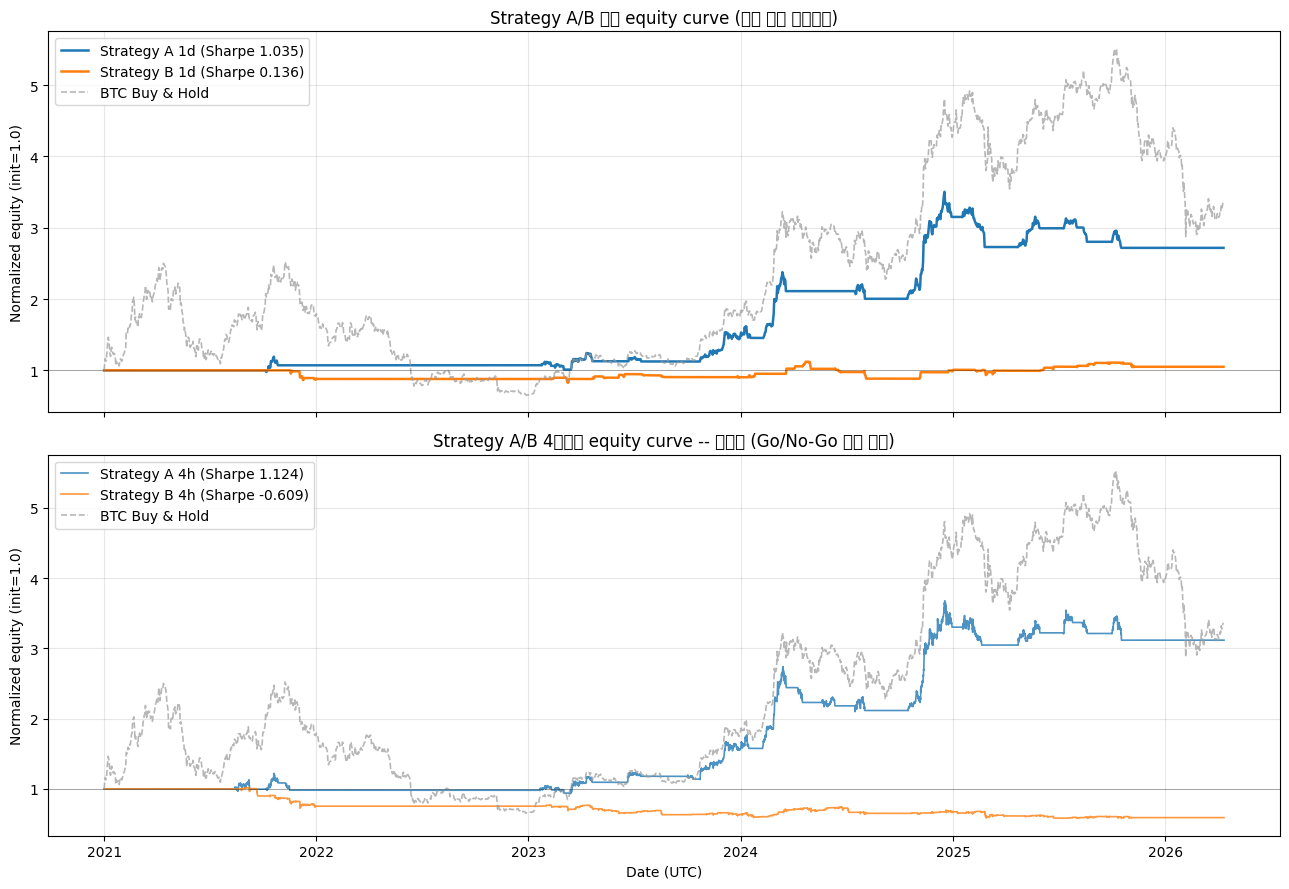

Saved: ../outputs/week1_equity_comparison.png


In [7]:
# === Equity curve 비교 차트 (4개 normalized) ===
eq_a_1d = pf_a_1d.value() / INIT_CASH
eq_b_1d = pf_b_1d.value() / INIT_CASH
eq_a_4h = pf_a_4h.value() / INIT_CASH
eq_b_4h = pf_b_4h.value() / INIT_CASH

# BTC Buy & Hold benchmark (일봉 기준)
btc_bh = df_1d['close'] / df_1d['close'].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# 상단: 일봉 (A vs B vs BTC BH)
ax = axes[0]
ax.plot(eq_a_1d.index, eq_a_1d.values, label=f"Strategy A 1d (Sharpe {m_a['sharpe']:.3f})", linewidth=1.8, color='#1f77b4')
ax.plot(eq_b_1d.index, eq_b_1d.values, label=f"Strategy B 1d (Sharpe {m_b['sharpe']:.3f})", linewidth=1.8, color='#ff7f0e')
ax.plot(btc_bh.index, btc_bh.values, label="BTC Buy & Hold", linewidth=1.2, color='#999999', linestyle='--', alpha=0.7)
ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.4)
ax.set_title("Strategy A/B 일봉 equity curve (사전 지정 파라미터)")
ax.set_ylabel("Normalized equity (init=1.0)")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# 하단: 4시간봉 (참고용 라벨)
ax = axes[1]
ax.plot(eq_a_4h.index, eq_a_4h.values, label=f"Strategy A 4h (Sharpe {result_4h['comparison']['strategy_a']['4h']['sharpe']:.3f})", linewidth=1.2, color='#1f77b4', alpha=0.8)
ax.plot(eq_b_4h.index, eq_b_4h.values, label=f"Strategy B 4h (Sharpe {result_4h['comparison']['strategy_b']['4h']['sharpe']:.3f})", linewidth=1.2, color='#ff7f0e', alpha=0.8)
ax.plot(btc_bh.index, btc_bh.values, label="BTC Buy & Hold", linewidth=1.2, color='#999999', linestyle='--', alpha=0.7)
ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.4)
ax.set_title("Strategy A/B 4시간봉 equity curve -- 참고용 (Go/No-Go 영향 없음)")
ax.set_ylabel("Normalized equity (init=1.0)")
ax.set_xlabel("Date (UTC)")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR / 'week1_equity_comparison.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")


In [8]:
# === W1-04 연도별 분할 표 ===
yearly = result_robust['yearly_breakdown']

rows = []
for strat_key, label in [('strategy_a', 'A'), ('strategy_b', 'B')]:
    for year, stats in yearly[strat_key].items():
        rows.append({
            'Strategy': label,
            'Year': year,
            'Return': stats['return'],
            'Sharpe': stats['sharpe'],
            'MDD': stats['mdd'],
            'Partial': stats['partial'],
        })
yearly_df = pd.DataFrame(rows)

# A/B 나란히 보이게 pivot
pivot = yearly_df.pivot(index='Year', columns='Strategy', values='Return') * 100
pivot_sharpe = yearly_df.pivot(index='Year', columns='Strategy', values='Sharpe')
pivot_mdd = yearly_df.pivot(index='Year', columns='Strategy', values='MDD') * 100

print("=" * 75)
print("W1-04 연도별 수익률 (%)")
print("=" * 75)
print(f"{'Year':<10} {'A Return':>10} {'B Return':>10} {'A Sharpe':>10} {'B Sharpe':>10} {'A MDD':>10} {'B MDD':>10}")
print("-" * 75)
for year in pivot.index:
    a_ret = pivot.loc[year, 'A']
    b_ret = pivot.loc[year, 'B']
    a_sr = pivot_sharpe.loc[year, 'A']
    b_sr = pivot_sharpe.loc[year, 'B']
    a_md = pivot_mdd.loc[year, 'A']
    b_md = pivot_mdd.loc[year, 'B']
    print(f"{year:<10} {a_ret:>9.2f}% {b_ret:>9.2f}% {a_sr:>10.4f} {b_sr:>10.4f} {a_md:>9.2f}% {b_md:>9.2f}%")

# 양수 연도 count (2026Q1 partial 제외, 정규 5년만)
full_years_a = [y for y, s in yearly['strategy_a'].items() if not s['partial']]
full_years_b = [y for y, s in yearly['strategy_b'].items() if not s['partial']]
positive_a = sum(1 for y in full_years_a if yearly['strategy_a'][y]['return'] > 0)
positive_b = sum(1 for y in full_years_b if yearly['strategy_b'][y]['return'] > 0)

print("-" * 75)
print(f"양수 연도 (정규 {len(full_years_a)}년 중):")
print(f"  A: {positive_a}개")
print(f"  B: {positive_b}개")
print(f"  최대: {max(positive_a, positive_b)}개  (Go 기준 >= 2)")

# Strategy A 2024 집중 리스크 경고
a_2024_ret = yearly['strategy_a']['2024']['return']
a_total_ret = m_a['total_return']
print(f"")
print(f"*** Strategy A 집중 리스크 경고 ***")
print(f"  2024년 수익: {a_2024_ret*100:.2f}%")
print(f"  5년 총수익:  {a_total_ret*100:.2f}%")
print(f"  -> 2024년 성과가 전체 수익의 상당 부분을 차지")
print(f"")
if result_robust['yearly_breakdown'].get('domination_warning_b', False):
    print(f"*** Strategy B domination warning ***")
    for line in result_robust['yearly_breakdown']['domination_details']:
        print(f"  {line}")
    print(f"  주: full-year total return이 매우 작아(4.94%) 연도별 기여도 비정상")
    print(f"  W1-04 evidence에 기술된 산술/기하 단위 한계 참고")


W1-04 연도별 수익률 (%)
Year         A Return   B Return   A Sharpe   B Sharpe      A MDD      B MDD
---------------------------------------------------------------------------
2021            7.02%    -13.16%     0.4789    -0.9289    -10.19%    -13.61%
2022            0.00%      1.21%     0.0000     0.4785      0.00%     -0.76%
2023           35.52%      2.76%     1.1248     0.2444     -9.84%     -8.80%
2024          117.30%      9.99%     2.0634     0.5267    -15.79%    -21.27%
2025          -13.77%      5.63%    -0.7148     0.3975    -17.22%     -7.36%
2026Q1*         0.00%      0.00%     0.0000     0.0000      0.00%      0.00%
---------------------------------------------------------------------------
양수 연도 (정규 5년 중):
  A: 3개
  B: 4개
  최대: 4개  (Go 기준 >= 2)

*** Strategy A 집중 리스크 경고 ***
  2024년 수익: 117.30%
  5년 총수익:  171.76%
  -> 2024년 성과가 전체 수익의 상당 부분을 차지

*** Strategy B domination warning ***
  Strategy B: 2021 contributes -266.6% of full-year total return
  Strategy B: 2024 contributes

In [9]:
# === W1-04 민감도 요약 (사전 지정 평탄도) ===
sens = result_robust['sensitivity']

print("=" * 70)
print("W1-04 민감도 요약 (사전 지정 파라미터가 평탄 영역에 있는가)")
print("=" * 70)
for strat_key, label in [('strategy_a', 'A'), ('strategy_b', 'B')]:
    s = sens[strat_key]
    print(f"")
    print(f"Strategy {label}:")
    print(f"  그리드 조합:         {s['total_combos']}  (NaN: {s['nan_combos']})")
    print(f"  사전 지정 Sharpe:    {s['pre_registered_sharpe']:.4f}")
    print(f"  주변 평탄도 std:     {s['flatness_neighborhood_std']:.4f}  (Go 기준 < 0.3)")
    print(f"  평탄 PASS:           {s['flatness_pass']}")


W1-04 민감도 요약 (사전 지정 파라미터가 평탄 영역에 있는가)

Strategy A:
  그리드 조합:         125  (NaN: 0)
  사전 지정 Sharpe:    1.0353
  주변 평탄도 std:     0.0440  (Go 기준 < 0.3)
  평탄 PASS:           True

Strategy B:
  그리드 조합:         125  (NaN: 0)
  사전 지정 Sharpe:    0.1362
  주변 평탄도 std:     0.1695  (Go 기준 < 0.3)
  평탄 PASS:           True


In [10]:
# === W1-05 4시간봉 비교 (참고용, Go/No-Go 영향 없음) ===
comp = result_4h['comparison']

print("=" * 75)
print("W1-05 일봉 vs 4시간봉 비교 -- 참고용 (Go/No-Go 영향 없음)")
print("=" * 75)
print(f"{'Strategy':<10} {'TF':<5} {'Sharpe':>8} {'Return':>10} {'MDD':>8} {'Trades':>7} {'WR':>7} {'PF':>6}")
print("-" * 75)
for strat_key, label in [('strategy_a', 'A'), ('strategy_b', 'B')]:
    for tf_key, tf_label in [('1d', '1D'), ('4h', '4h')]:
        m = comp[strat_key][tf_key]
        wr = f"{m['win_rate']*100:.1f}%" if not pd.isna(m.get('win_rate', float('nan'))) else "N/A"
        pf_s = f"{m['profit_factor']:.2f}" if not pd.isna(m.get('profit_factor', float('nan'))) else "N/A"
        print(f"{label:<10} {tf_label:<5} {m['sharpe']:>8.4f} {m['total_return']*100:>9.2f}% {m['max_drawdown']*100:>7.2f}% {m['total_trades']:>7.0f} {wr:>7} {pf_s:>6}")

print(f"")
print(f"Strategy A: 4h - 1d Sharpe diff = {comp['strategy_a']['sharpe_diff']:+.4f}  (robust: 차이 < 0.2)")
print(f"Strategy B: 4h - 1d Sharpe diff = {comp['strategy_b']['sharpe_diff']:+.4f}  (불안정: 4h 완전 실패)")
print(f"")
print(f"B 4h 패러독스: WR {comp['strategy_b']['4h']['win_rate']*100:.1f}% + PF {comp['strategy_b']['4h']['profit_factor']:.2f}")
print(f"  -> 자주 이기지만 큰 손실 소수가 다수 작은 이익 잠식")


W1-05 일봉 vs 4시간봉 비교 -- 참고용 (Go/No-Go 영향 없음)
Strategy   TF      Sharpe     Return      MDD  Trades      WR     PF
---------------------------------------------------------------------------
A          1D      1.0353    171.76%  -22.45%      14   50.0%   2.96
A          4h      1.1241    211.70%  -23.72%      20   50.0%   3.06
B          1D      0.1362      4.94%  -21.27%      39   53.8%   1.09
B          4h     -0.6088    -40.94%  -42.91%     207   60.4%   0.65

Strategy A: 4h - 1d Sharpe diff = +0.0888  (robust: 차이 < 0.2)
Strategy B: 4h - 1d Sharpe diff = -0.7450  (불안정: 4h 완전 실패)

B 4h 패러독스: WR 60.4% + PF 0.65
  -> 자주 이기지만 큰 손실 소수가 다수 작은 이익 잠식


In [11]:
# === Go 기준 5개 자동 평가 ===
yearly_a_positive = sum(1 for y, s in yearly['strategy_a'].items()
                        if not s['partial'] and s['return'] > 0)
yearly_b_positive = sum(1 for y, s in yearly['strategy_b'].items()
                        if not s['partial'] and s['return'] > 0)

go_criteria = {
    'A_sharpe_gt_0.8': {
        'value': m_a['sharpe'],
        'threshold': 0.8,
        'pass': m_a['sharpe'] > 0.8,
        'description': 'Strategy A 일봉 Sharpe > 0.8',
    },
    'B_sharpe_gt_0.5': {
        'value': m_b['sharpe'],
        'threshold': 0.5,
        'pass': m_b['sharpe'] > 0.5,
        'description': 'Strategy B 일봉 Sharpe > 0.5',
    },
    'any_mdd_lt_50pct': {
        'value_a': m_a['max_drawdown'],
        'value_b': m_b['max_drawdown'],
        'threshold': -0.5,
        'pass': (m_a['max_drawdown'] > -0.5) or (m_b['max_drawdown'] > -0.5),
        'description': '두 전략 중 하나라도 MDD < 50%',
    },
    'any_2plus_positive_years': {
        'value_a': yearly_a_positive,
        'value_b': yearly_b_positive,
        'threshold': 2,
        'pass': max(yearly_a_positive, yearly_b_positive) >= 2,
        'description': '두 전략 중 하나라도 5개 연도 중 최소 2개 양수',
    },
    'sensitivity_robust': {
        'value_a': sens['strategy_a']['flatness_pass'],
        'value_b': sens['strategy_b']['flatness_pass'],
        'pass': sens['strategy_a']['flatness_pass'] or sens['strategy_b']['flatness_pass'],
        'description': '사전 지정 파라미터가 민감도 평탄 영역 (둘 중 하나라도)',
    },
}

all_pass = all(c['pass'] for c in go_criteria.values())

print("=" * 75)
print("Go 기준 5개 자동 평가 (사전 지정 파라미터)")
print("=" * 75)
for key, c in go_criteria.items():
    status = 'PASS' if c['pass'] else 'FAIL'
    print(f"[{status}] {c['description']}")
    if key == 'A_sharpe_gt_0.8':
        print(f"       A Sharpe = {c['value']:.4f}")
    elif key == 'B_sharpe_gt_0.5':
        print(f"       B Sharpe = {c['value']:.4f}")
    elif key == 'any_mdd_lt_50pct':
        print(f"       A MDD = {c['value_a']*100:.2f}% | B MDD = {c['value_b']*100:.2f}%")
    elif key == 'any_2plus_positive_years':
        print(f"       A 양수 = {c['value_a']}개 | B 양수 = {c['value_b']}개")
    elif key == 'sensitivity_robust':
        print(f"       A robust = {c['value_a']} | B robust = {c['value_b']}")

print("")
print("=" * 75)
print(f"최종 판정 (모두 충족 룰): {'Go' if all_pass else 'No-Go'}")
print("=" * 75)

# Strategy A 단독 평가 (B 제외)
a_only_criteria = {
    'A_sharpe_gt_0.8': m_a['sharpe'] > 0.8,
    'A_mdd_lt_50pct': m_a['max_drawdown'] > -0.5,
    'A_2plus_positive_years': yearly_a_positive >= 2,
    'A_sensitivity_robust': sens['strategy_a']['flatness_pass'],
}
a_only_pass = all(a_only_criteria.values())
print(f"")
print(f"[참고] Strategy A 단독 평가 (B 제외):")
for k, v in a_only_criteria.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print(f"  A 단독 종합: {'PASS' if a_only_pass else 'FAIL'}")


Go 기준 5개 자동 평가 (사전 지정 파라미터)
[PASS] Strategy A 일봉 Sharpe > 0.8
       A Sharpe = 1.0353
[FAIL] Strategy B 일봉 Sharpe > 0.5
       B Sharpe = 0.1362
[PASS] 두 전략 중 하나라도 MDD < 50%
       A MDD = -22.45% | B MDD = -21.27%
[PASS] 두 전략 중 하나라도 5개 연도 중 최소 2개 양수
       A 양수 = 3개 | B 양수 = 4개
[PASS] 사전 지정 파라미터가 민감도 평탄 영역 (둘 중 하나라도)
       A robust = True | B robust = True

최종 판정 (모두 충족 룰): No-Go

[참고] Strategy A 단독 평가 (B 제외):
  [PASS] A_sharpe_gt_0.8
  [PASS] A_mdd_lt_50pct
  [PASS] A_2plus_positive_years
  [PASS] A_sensitivity_robust
  A 단독 종합: PASS


## W1-06 심화 분석: 2025-2026 구간 + 시장 국면(Regime) 라벨링

사용자 요청으로 최근 구간(2024-12-17 A DD peak 이후) 성과를 거래 단위와 **가격 기반
국면(regime)**으로 해부. 뉴스/거시 이벤트 해석은 사용하지 않는다 (post-hoc
rationalization 금지, CLAUDE.md Immutable "LLM은 매매 결정 생성자 아님" 룰 준수).
오직 가격/거래량 데이터로만 국면을 정의한다.

### Regime 정의 (mutually exclusive, 우선순위 order)

1. **Volatile**: 20일 수익률 표준편차가 전체 기간 상위 20% 초과
2. **Bear**: close < MA200 AND MA200 기울기(20일 변화율) 음수
3. **Bull**: close > MA200 AND MA200 기울기 양수
4. **Choppy**: 나머지 (횡보)

이 분류는 서술용이며 전략 진입 결정에는 쓰지 않는다. Volatile 임계값은 전체 기간으로
산정되어 일부 look-ahead 성격이 있지만, 사전 지정 파라미터 튜닝에는 쓰이지 않으므로
data snooping 아님.


In [12]:
# === A/B 거래 단위 분석 (2024-12-17 A DD peak 이후) ===
# vectorbt 0.28.5 records_readable: 'Entry Timestamp', 'Exit Timestamp' datetime64[ns, UTC] 이미 포함
trades_a = pf_a_1d.trades.records_readable.copy()
trades_b = pf_b_1d.trades.records_readable.copy()

print("A records_readable columns:", list(trades_a.columns))
print(f"A total trades: {len(trades_a)} | B total trades: {len(trades_b)}")

CUTOFF = pd.Timestamp('2024-12-17', tz='UTC')
trades_a_recent = trades_a[trades_a['Entry Timestamp'] >= CUTOFF].copy()
trades_b_recent = trades_b[trades_b['Entry Timestamp'] >= CUTOFF].copy()

print(f"\n--- A: Entry on/after 2024-12-17 ({len(trades_a_recent)} trades) ---")
for _, t in trades_a_recent.iterrows():
    print(f"  entry {str(t['Entry Timestamp'])[:10]} @ {t['Avg Entry Price']:>10,.0f}  ->  "
          f"exit {str(t['Exit Timestamp'])[:10]} @ {t['Avg Exit Price']:>10,.0f}  "
          f"PnL {t['PnL']:>+11,.0f}  ({t['Return']*100:+6.2f}%)  status={t['Status']}")

print(f"\n--- B: Entry on/after 2024-12-17 ({len(trades_b_recent)} trades) ---")
for _, t in trades_b_recent.iterrows():
    print(f"  entry {str(t['Entry Timestamp'])[:10]} @ {t['Avg Entry Price']:>10,.0f}  ->  "
          f"exit {str(t['Exit Timestamp'])[:10]} @ {t['Avg Exit Price']:>10,.0f}  "
          f"PnL {t['PnL']:>+11,.0f}  ({t['Return']*100:+6.2f}%)  status={t['Status']}")

# 연도별 trade count
def yr_mask(df, yr):
    return (df['Entry Timestamp'] >= pd.Timestamp(f'{yr}-01-01', tz='UTC')) & \
           (df['Entry Timestamp'] <  pd.Timestamp(f'{yr+1}-01-01', tz='UTC'))

print(f"\n--- 연도별 Trade Count ---")
print(f"{'Year':<6} {'A':>5} {'B':>5}")
for yr in [2021, 2022, 2023, 2024, 2025, 2026]:
    a_cnt = int(yr_mask(trades_a, yr).sum())
    b_cnt = int(yr_mask(trades_b, yr).sum())
    print(f"{yr:<6} {a_cnt:>5} {b_cnt:>5}")


A records_readable columns: ['Exit Trade Id', 'Column', 'Size', 'Entry Timestamp', 'Avg Entry Price', 'Entry Fees', 'Exit Timestamp', 'Avg Exit Price', 'Exit Fees', 'PnL', 'Return', 'Direction', 'Status', 'Position Id']
A total trades: 14 | B total trades: 39

--- A: Entry on/after 2024-12-17 (5 trades) ---
  entry 2025-01-17 @ 152,421,172  ->  exit 2025-02-24 @ 132,135,000  PnL    -422,175  (-13.40%)  status=Closed
  entry 2025-04-22 @ 133,921,928  ->  exit 2025-05-30 @ 146,970,478  PnL    +262,937  ( +9.64%)  status=Closed
  entry 2025-07-10 @ 156,597,260  ->  exit 2025-08-02 @ 157,297,312  PnL     +10,373  ( +0.35%)  status=Closed
  entry 2025-08-13 @ 168,135,026  ->  exit 2025-08-19 @ 157,093,414  PnL    -199,991  ( -6.66%)  status=Closed
  entry 2025-10-01 @ 168,508,212  ->  exit 2025-10-17 @ 163,557,180  PnL     -85,065  ( -3.04%)  status=Closed

--- B: Entry on/after 2024-12-17 (15 trades) ---
  entry 2024-12-23 @ 142,972,450  ->  exit 2024-12-24 @ 146,757,584  PnL     +24,763  

In [13]:
# === 가격 기반 시장 국면 라벨링 ===
daily_ret = df_1d['close'].pct_change()
ma200_1d = df_1d['close'].rolling(200).mean()
ma200_slope = ma200_1d.pct_change(20)
vol_20 = daily_ret.rolling(20).std() * np.sqrt(365)
vol_cut = float(vol_20.quantile(0.80))

regime_df = pd.DataFrame({
    'close': df_1d['close'],
    'ma200': ma200_1d,
    'slope': ma200_slope,
    'vol': vol_20,
})

def classify(row):
    if pd.isna(row['ma200']) or pd.isna(row['slope']) or pd.isna(row['vol']):
        return 'N/A'
    if row['vol'] > vol_cut:
        return 'Volatile'
    if row['close'] < row['ma200'] and row['slope'] < 0:
        return 'Bear'
    if row['close'] > row['ma200'] and row['slope'] > 0:
        return 'Bull'
    return 'Choppy'

regime_df['regime'] = regime_df.apply(classify, axis=1)
total_valid = int((regime_df['regime'] != 'N/A').sum())

print(f"=== Regime 분류 전체 ({total_valid} valid days, vol 상위 20% cut={vol_cut:.4f}) ===")
for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
    cnt = int((regime_df['regime'] == reg).sum())
    print(f"  {reg:<10s} {cnt:>5d} days ({cnt/total_valid*100:>5.1f}%)")

# 연도별 regime 비중
regime_df['year'] = regime_df.index.year
year_reg = regime_df[regime_df['regime'] != 'N/A'].groupby(['year', 'regime']).size().unstack(fill_value=0)
for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
    if reg not in year_reg.columns:
        year_reg[reg] = 0
year_reg = year_reg[['Bull', 'Bear', 'Choppy', 'Volatile']]
year_reg_pct = year_reg.div(year_reg.sum(axis=1), axis=0) * 100

print(f"\n=== 연도별 Regime 비중 (%) ===")
print(f"{'Year':<6} {'Bull':>8} {'Bear':>8} {'Choppy':>8} {'Volatile':>9}")
for y in year_reg_pct.index:
    print(f"{int(y):<6} {year_reg_pct.loc[y,'Bull']:>7.1f}% {year_reg_pct.loc[y,'Bear']:>7.1f}% "
          f"{year_reg_pct.loc[y,'Choppy']:>7.1f}% {year_reg_pct.loc[y,'Volatile']:>8.1f}%")


=== Regime 분류 전체 (1708 valid days, vol 상위 20% cut=0.6147) ===
  Bull         810 days ( 47.4%)
  Bear         393 days ( 23.0%)
  Choppy       268 days ( 15.7%)
  Volatile     237 days ( 13.9%)

=== 연도별 Regime 비중 (%) ===
Year       Bull     Bear   Choppy  Volatile
2021      59.6%     2.7%    14.4%     23.3%
2022       0.3%    64.7%    12.1%     23.0%
2023      67.4%     5.2%    24.1%      3.3%
2024      57.7%     5.7%    18.9%     17.8%
2025      72.6%     9.0%    12.6%      5.8%
2026       0.0%    79.2%     0.0%     20.8%


In [14]:
# === Regime × Strategy 성과 매트릭스 ===
a_ret = pf_a_1d.returns()
b_ret = pf_b_1d.returns()

regime_perf_rows = []
for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
    mask = (regime_df['regime'] == reg).values
    days = int(mask.sum())
    if days == 0:
        continue
    a_r = a_ret[mask]
    b_r = b_ret[mask]
    a_ann = float(a_r.mean() * 365)
    a_vol_r = float(a_r.std() * np.sqrt(365))
    a_sr = a_ann / a_vol_r if a_vol_r > 1e-12 else 0.0
    b_ann = float(b_r.mean() * 365)
    b_vol_r = float(b_r.std() * np.sqrt(365))
    b_sr = b_ann / b_vol_r if b_vol_r > 1e-12 else 0.0
    a_cum = float((1 + a_r).prod() - 1)
    b_cum = float((1 + b_r).prod() - 1)
    regime_perf_rows.append({
        'Regime': reg, 'Days': days, 'Pct': days/total_valid*100,
        'A_ann_ret': a_ann*100, 'A_Sharpe': a_sr, 'A_cum_ret': a_cum*100,
        'B_ann_ret': b_ann*100, 'B_Sharpe': b_sr, 'B_cum_ret': b_cum*100,
    })

regime_perf = pd.DataFrame(regime_perf_rows)

print("=" * 100)
print("Regime × Strategy 성과 (국면별, 전체 기간)")
print("=" * 100)
print(f"{'Regime':<10} {'Days':>6} {'Pct':>7} {'A_ann':>8} {'A_Sh':>7} {'A_cum':>9} {'B_ann':>8} {'B_Sh':>7} {'B_cum':>9}")
print("-" * 100)
for _, r in regime_perf.iterrows():
    print(f"{r['Regime']:<10} {r['Days']:>6} {r['Pct']:>6.1f}% "
          f"{r['A_ann_ret']:>7.2f}% {r['A_Sharpe']:>7.3f} {r['A_cum_ret']:>8.2f}% "
          f"{r['B_ann_ret']:>7.2f}% {r['B_Sharpe']:>7.3f} {r['B_cum_ret']:>8.2f}%")

# 2024-12-17 이후 regime 분포
recent_mask = regime_df.index >= CUTOFF
recent_valid = regime_df[recent_mask & (regime_df['regime'] != 'N/A')]
recent_n = len(recent_valid)
print(f"\n=== 2024-12-17 이후 ({recent_n} valid days) regime 분포 ===")
recent_breakdown = {}
for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
    cnt = int((recent_valid['regime'] == reg).sum())
    pct = cnt/recent_n*100 if recent_n > 0 else 0.0
    recent_breakdown[reg] = {'days': cnt, 'pct': pct}
    print(f"  {reg:<10s} {cnt:>4d} days ({pct:>5.1f}%)")

# 최근 A/B 성과
recent_a_ret = a_ret[recent_mask]
recent_b_ret = b_ret[recent_mask]
recent_a_cum = float((1 + recent_a_ret).prod() - 1) * 100
recent_b_cum = float((1 + recent_b_ret).prod() - 1) * 100
recent_a_sr = float(recent_a_ret.mean() * 365 / (recent_a_ret.std() * np.sqrt(365))) if recent_a_ret.std() > 0 else 0.0
recent_b_sr = float(recent_b_ret.mean() * 365 / (recent_b_ret.std() * np.sqrt(365))) if recent_b_ret.std() > 0 else 0.0
print(f"\n=== 2024-12-17 이후 누적 성과 ===")
print(f"  A cum return: {recent_a_cum:+.2f}%  Sharpe {recent_a_sr:.4f}")
print(f"  B cum return: {recent_b_cum:+.2f}%  Sharpe {recent_b_sr:.4f}")


Regime × Strategy 성과 (국면별, 전체 기간)
Regime       Days     Pct    A_ann    A_Sh     A_cum    B_ann    B_Sh     B_cum
----------------------------------------------------------------------------------------------------
Bull          810   47.4%   17.85%   0.739    39.38%    2.24%   0.157     2.72%
Bear          393   23.0%    0.00%   0.000     0.00%    0.00%   0.000     0.00%
Choppy        268   15.7%   26.54%   1.638    20.37%  -12.35%  -0.773    -9.51%
Volatile      237   13.9%   79.37%   2.467    61.99%   19.54%   1.458    12.89%



=== 2024-12-17 이후 (481 valid days) regime 분포 ===
  Bull        280 days ( 58.2%)
  Bear        113 days ( 23.5%)
  Choppy       46 days (  9.6%)
  Volatile     42 days (  8.7%)

=== 2024-12-17 이후 누적 성과 ===
  A cum return: -21.53%  Sharpe -1.1435
  B cum return: +7.84%  Sharpe 0.5409


/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/2040077653.py:52: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/2040077653.py:52: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/2040077653.py:52: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/2040077653.py:52: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ipykernel_47937/2040077653.py:52: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/y4cccdcs08z55qw7qhk4_tdr0000gn/T/ip

/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coin-bot/research/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kyounghwanlee/Desktop/coi

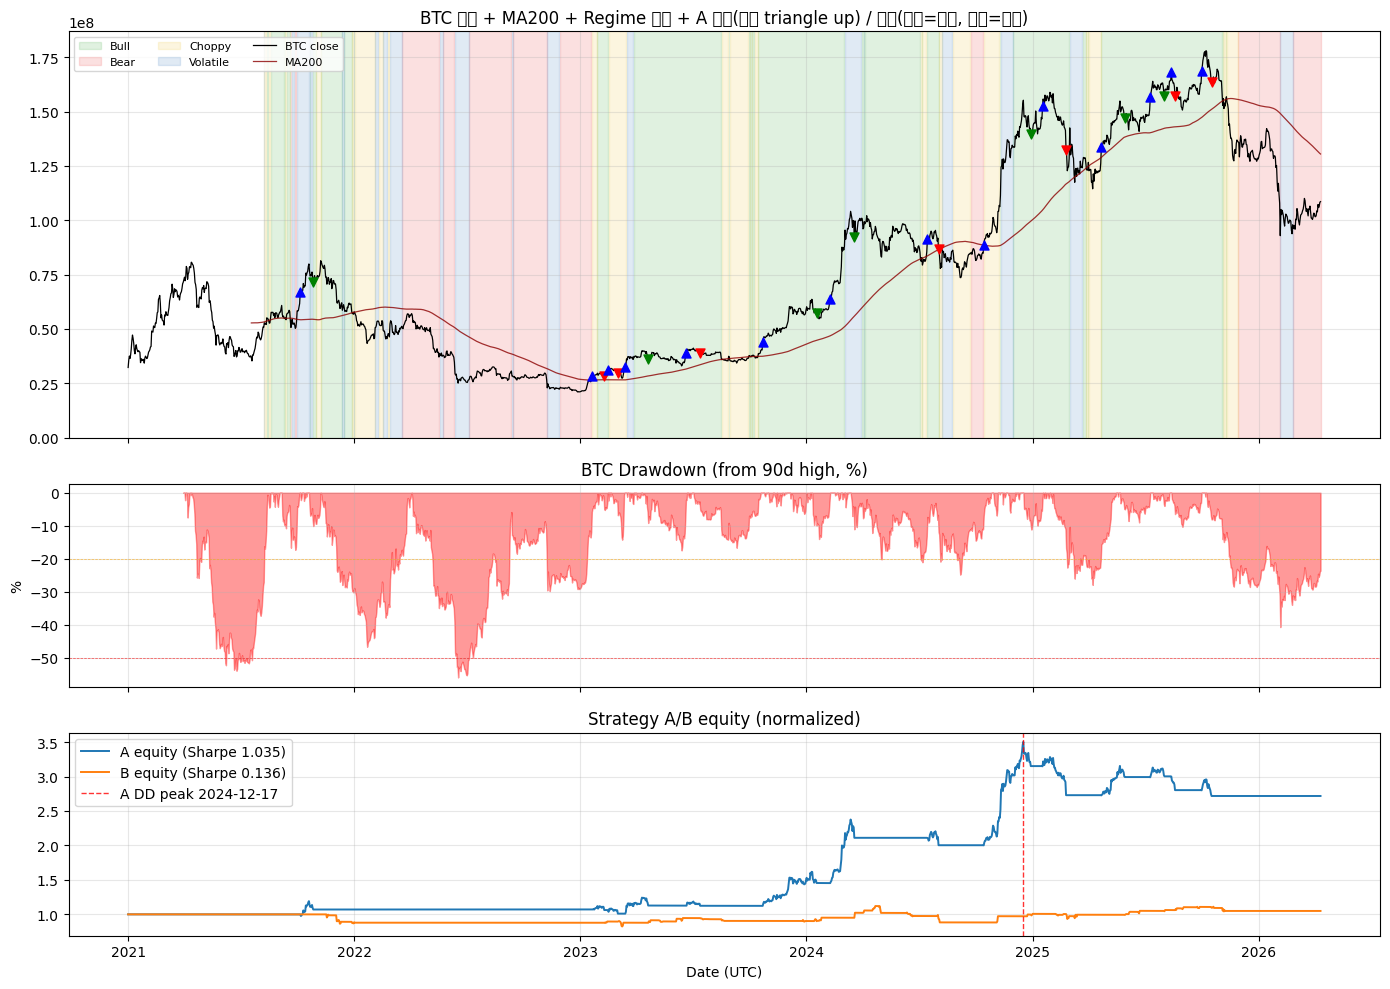

Saved: ../outputs/week1_regime_analysis.png


In [15]:
# === Regime + 가격 + A 진입 시각화 ===
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1]})

# Top: 가격 + MA200 + regime 배경
ax = axes[0]
regime_colors = {'Bull': '#66bb66', 'Bear': '#ee6666', 'Choppy': '#f0d060', 'Volatile': '#6699cc'}
price_max = df_1d['close'].max() * 1.05
for reg, color in regime_colors.items():
    mask = (regime_df['regime'] == reg).values
    ax.fill_between(df_1d.index, 0, price_max, where=mask,
                    alpha=0.20, color=color, step='post', label=reg)
ax.plot(df_1d.index, df_1d['close'], color='black', linewidth=0.9, label='BTC close')
ax.plot(df_1d.index, ma200_1d, color='darkred', linewidth=0.9, label='MA200', alpha=0.8)

# A 거래 entry/exit 마커
for _, t in trades_a.iterrows():
    pnl = t['PnL']
    color_m = 'green' if pnl > 0 else 'red'
    ax.scatter([t['Entry Timestamp']], [t['Avg Entry Price']], marker='^', color='blue', s=42, zorder=5)
    ax.scatter([t['Exit Timestamp']], [t['Avg Exit Price']], marker='v', color=color_m, s=42, zorder=5)

ax.set_ylim(0, price_max)
ax.set_title('BTC 가격 + MA200 + Regime 배경 + A 진입(파란 triangle up) / 청산(녹색=익절, 빨강=손실)')
ax.legend(loc='upper left', ncol=3, fontsize=8)
ax.grid(alpha=0.3)

# Mid: Drawdown from 90d high
high_90 = df_1d['close'].rolling(90).max()
dd_90 = (df_1d['close'] / high_90 - 1) * 100
ax = axes[1]
ax.fill_between(df_1d.index, 0, dd_90.values, color='red', alpha=0.4)
ax.axhline(-20, color='orange', linewidth=0.5, linestyle='--', alpha=0.7)
ax.axhline(-50, color='red', linewidth=0.5, linestyle='--', alpha=0.7)
ax.set_title('BTC Drawdown (from 90d high, %)')
ax.set_ylabel('%')
ax.grid(alpha=0.3)

# Bottom: A/B equity + DD peak 표시
eq_a = pf_a_1d.value() / INIT_CASH
eq_b = pf_b_1d.value() / INIT_CASH
ax = axes[2]
ax.plot(eq_a.index, eq_a.values, color='#1f77b4', linewidth=1.4, label=f"A equity (Sharpe {m_a['sharpe']:.3f})")
ax.plot(eq_b.index, eq_b.values, color='#ff7f0e', linewidth=1.4, label=f"B equity (Sharpe {m_b['sharpe']:.3f})")
dd_peak = pd.Timestamp('2024-12-17', tz='UTC')
ax.axvline(dd_peak, color='red', linewidth=1, linestyle='--', alpha=0.8, label='A DD peak 2024-12-17')
ax.set_title('Strategy A/B equity (normalized)')
ax.set_xlabel('Date (UTC)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
chart_path = OUT_DIR / 'week1_regime_analysis.png'
plt.savefig(chart_path, dpi=110, bbox_inches='tight')
plt.show()
print(f"Saved: {chart_path}")


In [16]:
# === 의사결정 시나리오 3개 ===
print("=" * 75)
print("의사결정 시나리오 -- 사용자 결정 사항")
print("=" * 75)

print("")
print("[Option A] Strategy A 단독 Go")
print("  - B 폐기, A로 Week 2 walk-forward 진행")
print("  - 근거: A는 5개 기준 중 A 해당 조항 모두 PASS, B는 FAIL")
print("  - 리스크: 단일 전략 의존. 2025년 -13.77%, 480일 DD 미회복 중")
print("  - 필요 후속: Week 2에서 보조 전략 탐색 병행 검토")
print("")
print("[Option B] No-Go")
print("  - '모두 충족' 룰 엄격 적용 -> Stage 1 킬 카운터 +1")
print("  - Week 2 전체를 전략 패밀리 재탐색에 사용")
print("  - 후보: 모멘텀(MACD/ADX), 변동성 브레이크아웃, 통계적 차익거래 등")
print("  - 리스크: A 검증 결과 활용도 낮음, 진행 지연")
print("")
print("[Option C] Strategy A Go + B 자리 재탐색 (병행)")
print("  - A로 Week 2 walk-forward 시작")
print("  - 동시에 B 폐기 후 새로운 보조 전략 후보 사전 등록 + 탐색")
print("  - 리스크: Week 2 작업량 증가, 두 트랙 병행 복잡도")
print("  - 주의: 같은 데이터로 튜닝 반복 금지. OOS 데이터(알트, 다른 거래소) 사용")
print("")
print("프로젝트 목표 ('안정적인 수익 구조') 관점:")
print("  - Option A: 단일 엣지 확립은 됐으나 분산 부족")
print("  - Option B: 깨끗한 재설계, 그러나 기존 A 증거 활용 못함")
print("  - Option C: 분산 확보 지향, 복잡도 관리 필요")
print("")
print("결정은 사용자 몫. W1-06.4에서 보고 후 명시적 승인 받기.")


의사결정 시나리오 -- 사용자 결정 사항

[Option A] Strategy A 단독 Go
  - B 폐기, A로 Week 2 walk-forward 진행
  - 근거: A는 5개 기준 중 A 해당 조항 모두 PASS, B는 FAIL
  - 리스크: 단일 전략 의존. 2025년 -13.77%, 480일 DD 미회복 중
  - 필요 후속: Week 2에서 보조 전략 탐색 병행 검토

[Option B] No-Go
  - '모두 충족' 룰 엄격 적용 -> Stage 1 킬 카운터 +1
  - Week 2 전체를 전략 패밀리 재탐색에 사용
  - 후보: 모멘텀(MACD/ADX), 변동성 브레이크아웃, 통계적 차익거래 등
  - 리스크: A 검증 결과 활용도 낮음, 진행 지연

[Option C] Strategy A Go + B 자리 재탐색 (병행)
  - A로 Week 2 walk-forward 시작
  - 동시에 B 폐기 후 새로운 보조 전략 후보 사전 등록 + 탐색
  - 리스크: Week 2 작업량 증가, 두 트랙 병행 복잡도
  - 주의: 같은 데이터로 튜닝 반복 금지. OOS 데이터(알트, 다른 거래소) 사용

프로젝트 목표 ('안정적인 수익 구조') 관점:
  - Option A: 단일 엣지 확립은 됐으나 분산 부족
  - Option B: 깨끗한 재설계, 그러나 기존 A 증거 활용 못함
  - Option C: 분산 확보 지향, 복잡도 관리 필요

결정은 사용자 몫. W1-06.4에서 보고 후 명시적 승인 받기.


In [17]:
# === week1_report.md 자동 생성 ===

def build_report_md():
    lines = []
    lines.append("# Week 1 결과 리포트")
    lines.append("")
    lines.append(f"생성일시: {datetime.now(timezone.utc).isoformat()}")
    lines.append(f"데이터 해시 (1d): `{hash_1d}`")
    lines.append(f"데이터 해시 (4h): `{hash_4h}`")
    lines.append("")
    lines.append("## 1. 데이터 (W1-01)")
    lines.append("")
    lines.append(f"- 기간: {data_1d_info['range'][0]} ~ {data_1d_info['range'][1]}")
    lines.append(f"- 일봉: {data_1d_info['bars']} bars")
    lines.append(f"- 4시간봉: {data_4h_info['bars']} bars")
    lines.append("")
    lines.append("## 2. Strategy A 일봉 (추세 추종, 사전 지정) -- W1-02")
    lines.append("")
    lines.append(f"파라미터: MA={p_a['ma_period']}, Donchian={p_a['donchian_high']}/{p_a['donchian_low']}, Vol>{p_a['vol_mult']}x, SL={p_a['sl_pct']*100:.0f}%")
    lines.append("")
    lines.append("| 지표 | 값 | Go 기준 |")
    lines.append("|------|-----|---------|")
    lines.append(f"| Sharpe | **{m_a['sharpe']:.4f}** | > 0.8 |")
    lines.append(f"| Sharpe 95% CI (Lo 2002) | [{m_a['sharpe_ci_95_normal'][0]:.4f}, {m_a['sharpe_ci_95_normal'][1]:.4f}] | -- |")
    lines.append(f"| Total Return | {m_a['total_return']*100:.2f}% | -- |")
    lines.append(f"| Max Drawdown | {m_a['max_drawdown']*100:.2f}% | < 50% |")
    lines.append(f"| Deepest DD duration | {m_a['deepest_drawdown']['duration_days']}일 ({m_a['deepest_drawdown']['status']}) | -- |")
    lines.append(f"| Trades | {m_a['total_trades']} | -- |")
    lines.append(f"| Win Rate | {m_a['win_rate']*100:.2f}% | -- |")
    lines.append(f"| Profit Factor | {m_a['profit_factor']:.4f} | -- |")
    lines.append("")
    lines.append(f"**Caveat**: Deepest DD active (peak {m_a['deepest_drawdown']['peak_timestamp'][:10]}, "
                 f"{m_a['deepest_drawdown']['duration_days']}일 미회복). Trades N={m_a['total_trades']} (low-N).")
    lines.append("")
    lines.append("## 3. Strategy B 일봉 (평균 회귀, 사전 지정) -- W1-03")
    lines.append("")
    lines.append(f"파라미터: MA={p_b['ma_period']}, RSI({p_b['rsi_period']})<{p_b['rsi_buy']} entry, RSI>{p_b['rsi_sell']} exit, TimeStop={p_b['time_stop_days']}d, SL={p_b['sl_pct']*100:.0f}%")
    lines.append("")
    lines.append("| 지표 | 값 | Go 기준 |")
    lines.append("|------|-----|---------|")
    lines.append(f"| Sharpe | **{m_b['sharpe']:.4f}** | > 0.5 |")
    lines.append(f"| Sharpe 95% CI (Lo 2002) | [{m_b['sharpe_ci_95_normal'][0]:.4f}, {m_b['sharpe_ci_95_normal'][1]:.4f}] | -- |")
    lines.append(f"| Total Return | {m_b['total_return']*100:.2f}% | -- |")
    lines.append(f"| Max Drawdown | {m_b['max_drawdown']*100:.2f}% | < 50% |")
    lines.append(f"| Deepest DD duration | {m_b['deepest_drawdown']['duration_days']}일 ({m_b['deepest_drawdown']['status']}) | -- |")
    lines.append(f"| Trades | {m_b['total_trades']} | -- |")
    lines.append(f"| Win Rate | {m_b['win_rate']*100:.2f}% | -- |")
    lines.append(f"| Profit Factor | {m_b['profit_factor']:.4f} | -- |")
    lines.append("")
    lines.append(f"**Caveat**: Sharpe 0.14 수준은 실질적으로 무수익. PF 1.09 (번 돈 ≈ 잃은 돈). 2021년 -13.16% 손실이 5년 전체 성과 잠식.")
    lines.append("")
    lines.append("## 4. 강건성 + 민감도 (W1-04)")
    lines.append("")
    lines.append("### 4.1 연도별 분할 (정규 5년 + 2026Q1 partial)")
    lines.append("")
    lines.append("| 연도 | A Return | B Return | A Sharpe | B Sharpe | A MDD | B MDD |")
    lines.append("|------|----------|----------|----------|----------|-------|-------|")
    for year in pivot.index:
        lines.append(f"| {year} | {pivot.loc[year,'A']:.2f}% | {pivot.loc[year,'B']:.2f}% | "
                     f"{pivot_sharpe.loc[year,'A']:.4f} | {pivot_sharpe.loc[year,'B']:.4f} | "
                     f"{pivot_mdd.loc[year,'A']:.2f}% | {pivot_mdd.loc[year,'B']:.2f}% |")
    lines.append("")
    lines.append(f"- A 양수 연도: {positive_a}개 (정규 5년 중, 2022년 return=0은 중립 제외)")
    lines.append(f"- B 양수 연도: {positive_b}개 (정규 5년 중)")
    lines.append(f"- Go 기준 >= 2: **PASS** (둘 다 충족)")
    lines.append("")
    lines.append(f"**Strategy A 집중 리스크**: 2024년 수익 {yearly['strategy_a']['2024']['return']*100:.2f}% / 5년 총 {m_a['total_return']*100:.2f}%")
    lines.append(f" -> 2024년 단일 연도가 전체 성과의 대부분 차지.")
    lines.append("")
    lines.append("**B domination warning** (W1-04 evidence): total return이 매우 작아 연도별 기여도가 -266% ~ +202%로 비정상 표시. 산술/기하 단위 불일치 한계. absolute return 기반 해석이 적절.")
    lines.append("")
    lines.append("### 4.2 민감도 (사전 지정 파라미터의 평탄도)")
    lines.append("")
    lines.append("| 전략 | 그리드 | NaN | 사전 지정 Sharpe | 평탄도 std | PASS |")
    lines.append("|------|--------|-----|------------------|-----------|------|")
    for k, lbl in [('strategy_a', 'A'), ('strategy_b', 'B')]:
        s = sens[k]
        lines.append(f"| {lbl} | {s['total_combos']} | {s['nan_combos']} | "
                     f"{s['pre_registered_sharpe']:.4f} | {s['flatness_neighborhood_std']:.4f} | {s['flatness_pass']} |")
    lines.append("")
    lines.append("민감도 그리드는 **참고용**. 사전 지정 파라미터만 Go/No-Go 평가에 사용.")
    lines.append("")
    lines.append("## 5. 4시간봉 포팅 (참고용, Go/No-Go 영향 없음) -- W1-05")
    lines.append("")
    lines.append("| 전략 | TF | Sharpe | Return | MDD | Trades | Win Rate | PF |")
    lines.append("|------|-----|--------|--------|-----|--------|----------|-----|")
    for k, lbl in [('strategy_a', 'A'), ('strategy_b', 'B')]:
        for tf, tflbl in [('1d', '1D'), ('4h', '4h')]:
            mm = comp[k][tf]
            wr = f"{mm['win_rate']*100:.2f}%" if not pd.isna(mm.get('win_rate', float('nan'))) else "N/A"
            pfs = f"{mm['profit_factor']:.4f}" if not pd.isna(mm.get('profit_factor', float('nan'))) else "N/A"
            lines.append(f"| {lbl} | {tflbl} | {mm['sharpe']:.4f} | {mm['total_return']*100:.2f}% | "
                         f"{mm['max_drawdown']*100:.2f}% | {mm['total_trades']} | {wr} | {pfs} |")
    lines.append("")
    lines.append(f"- A 4h-1d Sharpe diff = {comp['strategy_a']['sharpe_diff']:+.4f} (robust, 차이 < 0.2)")
    lines.append(f"- B 4h-1d Sharpe diff = {comp['strategy_b']['sharpe_diff']:+.4f} (4h 완전 실패)")
    lines.append(f"- B 4h 패러독스: WR {comp['strategy_b']['4h']['win_rate']*100:.2f}% + PF {comp['strategy_b']['4h']['profit_factor']:.4f}")
    lines.append("")
    lines.append("## 6. 2025-2026 심화 분석 (W1-06 추가)")
    lines.append("")
    lines.append("가격 기반 시장 국면(regime) 라벨링. 뉴스/거시 해석 사용 금지 (post-hoc rationalization, LLM Phase 10+ Immutable 룰 준수).")
    lines.append("")
    lines.append("### 6.1 Regime 정의")
    lines.append("")
    lines.append("- **Volatile**: 20일 수익률 표준편차가 전체 기간 상위 20% 초과")
    lines.append("- **Bear**: close < MA200 AND MA200 기울기(20일 변화율) < 0")
    lines.append("- **Bull**: close > MA200 AND MA200 기울기 > 0")
    lines.append("- **Choppy**: 나머지")
    lines.append("")
    lines.append(f"Volatile 임계값: 연율화 std > {vol_cut:.4f}")
    lines.append("")
    lines.append("### 6.2 전체 기간 Regime 분포")
    lines.append("")
    lines.append("| Regime | Days | Pct |")
    lines.append("|--------|------|-----|")
    for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
        cnt = int((regime_df['regime'] == reg).sum())
        pct = cnt/total_valid*100
        lines.append(f"| {reg} | {cnt} | {pct:.1f}% |")
    lines.append("")
    lines.append("### 6.3 연도별 Regime 비중 (%)")
    lines.append("")
    lines.append("| Year | Bull | Bear | Choppy | Volatile |")
    lines.append("|------|------|------|--------|----------|")
    for y in year_reg_pct.index:
        lines.append(f"| {int(y)} | {year_reg_pct.loc[y,'Bull']:.1f}% | {year_reg_pct.loc[y,'Bear']:.1f}% | "
                     f"{year_reg_pct.loc[y,'Choppy']:.1f}% | {year_reg_pct.loc[y,'Volatile']:.1f}% |")
    lines.append("")
    lines.append("### 6.4 Regime × Strategy 성과 (전체 기간)")
    lines.append("")
    lines.append("| Regime | Days | Pct | A ann ret | A Sharpe | A cum | B ann ret | B Sharpe | B cum |")
    lines.append("|--------|------|-----|-----------|----------|-------|-----------|----------|-------|")
    for _, r in regime_perf.iterrows():
        lines.append(f"| {r['Regime']} | {r['Days']} | {r['Pct']:.1f}% | "
                     f"{r['A_ann_ret']:.2f}% | {r['A_Sharpe']:.3f} | {r['A_cum_ret']:.2f}% | "
                     f"{r['B_ann_ret']:.2f}% | {r['B_Sharpe']:.3f} | {r['B_cum_ret']:.2f}% |")
    lines.append("")
    lines.append(f"### 6.5 2024-12-17 이후 구간 (A DD peak 기준, {recent_n} valid days)")
    lines.append("")
    lines.append("| Regime | Days | Pct |")
    lines.append("|--------|------|-----|")
    for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']:
        d = recent_breakdown[reg]
        lines.append(f"| {reg} | {d['days']} | {d['pct']:.1f}% |")
    lines.append("")
    lines.append(f"**누적 성과 (2024-12-17 ~ 현재)**:")
    lines.append(f"- Strategy A: {recent_a_cum:+.2f}% (Sharpe {recent_a_sr:.4f})")
    lines.append(f"- Strategy B: {recent_b_cum:+.2f}% (Sharpe {recent_b_sr:.4f})")
    lines.append("")
    lines.append(f"**Trade 수 (2024-12-17 이후)**: A {len(trades_a_recent)}개 / B {len(trades_b_recent)}개")
    lines.append("")
    lines.append("### 6.6 해석 (가격 기반만)")
    lines.append("")
    # Best/worst regime for each
    rp_sorted_a = regime_perf.sort_values('A_Sharpe', ascending=False)
    rp_sorted_b = regime_perf.sort_values('B_Sharpe', ascending=False)
    best_a = rp_sorted_a.iloc[0]; worst_a = rp_sorted_a.iloc[-1]
    best_b = rp_sorted_b.iloc[0]; worst_b = rp_sorted_b.iloc[-1]
    recent_dom = max(recent_breakdown.items(), key=lambda x: x[1]['days'])[0]
    lines.append(f"- **Strategy A**: {best_a['Regime']} regime 최고 (Sharpe {best_a['A_Sharpe']:.3f}), "
                 f"{worst_a['Regime']} 최저 (Sharpe {worst_a['A_Sharpe']:.3f})")
    lines.append(f"- **Strategy B**: {best_b['Regime']} regime 최고 (Sharpe {best_b['B_Sharpe']:.3f}), "
                 f"{worst_b['Regime']} 최저 (Sharpe {worst_b['B_Sharpe']:.3f})")
    lines.append(f"- **2024-12-17 이후 dominant regime**: {recent_dom} ({recent_breakdown[recent_dom]['pct']:.1f}%)")
    if best_a['Regime'] != best_b['Regime']:
        lines.append(f"- **상호 보완성**: A/B가 서로 다른 regime에서 우위 -> 앙상블 시 분산 효과 기대 가능 (Week 2+ 검토)")
    else:
        lines.append(f"- **상호 보완성 낮음**: A/B 모두 같은 regime({best_a['Regime']})에서 우위 -> 앙상블 효과 제한적")
    lines.append("")
    lines.append("## 7. Go/No-Go 평가")
    lines.append("")
    lines.append("### 7.1 기준 5개 (모두 충족 시 Go)")
    lines.append("")
    for key, c in go_criteria.items():
        mark = 'PASS' if c['pass'] else 'FAIL'
        lines.append(f"- **[{mark}]** {c['description']}")
    lines.append("")
    lines.append(f"### 7.2 최종 판정 (모두 충족 룰): **{'Go' if all_pass else 'No-Go'}**")
    lines.append("")
    lines.append(f"Strategy B Sharpe 0.14가 기준 0.5 미달 -> 엄격 적용 시 No-Go.")
    lines.append(f"Strategy A 단독으로는 4개 조건 모두 PASS -> Conditional Go 옵션 존재.")
    lines.append("")
    lines.append("### 7.3 의사결정 옵션 (사용자 결정)")
    lines.append("")
    lines.append("**Option A -- Strategy A 단독 Go**")
    lines.append("- B 폐기, A로 Week 2 walk-forward 진행")
    lines.append("- 리스크: 단일 전략 의존, A의 2025년 -13.77%, 480일 DD 미회복")
    lines.append("")
    lines.append("**Option B -- No-Go**")
    lines.append("- Stage 1 킬 카운터 +1, Week 2 전체를 전략 재탐색에 사용")
    lines.append("- 리스크: A 증거 활용도 낮음, 진행 지연")
    lines.append("")
    lines.append("**Option C -- A Go + B 자리 재탐색 (병행)**")
    lines.append("- A로 walk-forward 시작 + B 폐기 후 새 보조 전략 사전 등록")
    lines.append("- 리스크: Week 2 복잡도 증가")
    lines.append("- **섹션 6 심화 분석 결과가 이 옵션 설득력에 영향** (regime 상호 보완성 있으면 +, 없으면 -)")
    lines.append("")
    lines.append("### 7.4 프로젝트 목표 관점")
    lines.append("")
    lines.append("프로젝트 북극성 = **안정적인 수익 구조**.")
    lines.append("- Data snooping (결과 본 후 파라미터 튜닝, Go 기준 사후 하향)은 명시적 금지.")
    lines.append("- 깨끗한 No-Go가 오염된 Go보다 낫다.")
    lines.append("- 사용자 명시적 승인 없이 Week 2 자동 진행 금지.")
    lines.append("")
    lines.append("### 7.5 사용자 결정 기록")
    lines.append("")
    lines.append("- 결정: _TBD_ (사용자 입력 대기)")
    lines.append("- 결정 일시: _TBD_")
    lines.append("- 근거: _TBD_")
    lines.append("")
    lines.append("---")
    lines.append("")
    lines.append(f"End of Week 1 report. Generated by `06_week1_report.ipynb` at {datetime.now(timezone.utc).isoformat()}.")
    return '\n'.join(lines)

report_md = build_report_md()
report_path = OUT_DIR / 'week1_report.md'
with open(report_path, 'w') as f:
    f.write(report_md)
print(f"Saved: {report_path}")
print(f"Length: {len(report_md)} chars, {report_md.count(chr(10))+1} lines")


Saved: ../outputs/week1_report.md
Length: 6240 chars, 200 lines


In [18]:
# === week1_summary.json 저장 ===
summary = {
    'task_id': 'W1-06',
    'feature_id': 'REPORT-001',
    'analysis_type': 'week1_aggregation',
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'data': {
        '1d': {'file': PARQUET_1D, 'hash': hash_1d, 'bars': data_1d_info['bars'],
               'range': data_1d_info['range']},
        '4h': {'file': PARQUET_4H, 'hash': hash_4h, 'bars': data_4h_info['bars'],
               'range': data_4h_info['range']},
    },
    'strategy_a_daily': {
        'parameters': p_a,
        'metrics': m_a,
    },
    'strategy_b_daily': {
        'parameters': p_b,
        'metrics': m_b,
    },
    'robustness': {
        'yearly_positive_count': {
            'strategy_a': positive_a,
            'strategy_b': positive_b,
            'full_years_evaluated': len(full_years_a),
        },
        'strategy_a_concentration_2024': {
            'year_return': yearly['strategy_a']['2024']['return'],
            'total_return': m_a['total_return'],
            'ratio': yearly['strategy_a']['2024']['return'] / m_a['total_return'] if m_a['total_return'] != 0 else None,
        },
        'sensitivity': {
            'strategy_a': {
                'flatness_std': sens['strategy_a']['flatness_neighborhood_std'],
                'flatness_pass': sens['strategy_a']['flatness_pass'],
            },
            'strategy_b': {
                'flatness_std': sens['strategy_b']['flatness_neighborhood_std'],
                'flatness_pass': sens['strategy_b']['flatness_pass'],
            },
        },
    },
    'reference_4h': {
        'strategy_a_sharpe_diff': comp['strategy_a']['sharpe_diff'],
        'strategy_b_sharpe_diff': comp['strategy_b']['sharpe_diff'],
        'note': 'Reference only. NOT Go/No-Go basis.',
    },
    'regime_analysis': {
        'note': 'Price-based regime labeling (no news/macro). Added in W1-06.1b.',
        'regime_definition': {
            'Volatile': '20d returns std > 80th percentile (annualized)',
            'Bear': 'close < MA200 AND MA200 slope(20d) < 0',
            'Bull':  'close > MA200 AND MA200 slope(20d) > 0',
            'Choppy': 'otherwise',
            'volatile_cutoff_ann_std': float(vol_cut),
        },
        'overall_distribution': {
            reg: {
                'days': int((regime_df['regime'] == reg).sum()),
                'pct':  float((regime_df['regime'] == reg).sum() / total_valid * 100),
            } for reg in ['Bull', 'Bear', 'Choppy', 'Volatile']
        },
        'yearly_distribution_pct': {
            str(int(y)): {
                'Bull':     float(year_reg_pct.loc[y, 'Bull']),
                'Bear':     float(year_reg_pct.loc[y, 'Bear']),
                'Choppy':   float(year_reg_pct.loc[y, 'Choppy']),
                'Volatile': float(year_reg_pct.loc[y, 'Volatile']),
            } for y in year_reg_pct.index
        },
        'regime_x_strategy_performance': [
            {
                'Regime': r['Regime'], 'Days': int(r['Days']), 'Pct': float(r['Pct']),
                'A_ann_ret_pct': float(r['A_ann_ret']), 'A_Sharpe': float(r['A_Sharpe']),
                'A_cum_ret_pct': float(r['A_cum_ret']),
                'B_ann_ret_pct': float(r['B_ann_ret']), 'B_Sharpe': float(r['B_Sharpe']),
                'B_cum_ret_pct': float(r['B_cum_ret']),
            } for _, r in regime_perf.iterrows()
        ],
        'post_2024_12_17': {
            'cutoff': CUTOFF.isoformat(),
            'total_valid_days': int(recent_n),
            'regime_distribution': recent_breakdown,
            'strategy_a_cumulative_return_pct': float(recent_a_cum),
            'strategy_a_sharpe': float(recent_a_sr),
            'strategy_b_cumulative_return_pct': float(recent_b_cum),
            'strategy_b_sharpe': float(recent_b_sr),
            'strategy_a_trades_count': int(len(trades_a_recent)),
            'strategy_b_trades_count': int(len(trades_b_recent)),
            'strategy_a_recent_trades': [
                {
                    'entry': str(t['Entry Timestamp'])[:10],
                    'exit':  str(t['Exit Timestamp'])[:10],
                    'entry_price': float(t['Avg Entry Price']),
                    'exit_price':  float(t['Avg Exit Price']),
                    'pnl': float(t['PnL']),
                    'return_pct': float(t['Return']) * 100,
                    'status': str(t['Status']),
                } for _, t in trades_a_recent.iterrows()
            ],
            'strategy_b_recent_trades': [
                {
                    'entry': str(t['Entry Timestamp'])[:10],
                    'exit':  str(t['Exit Timestamp'])[:10],
                    'entry_price': float(t['Avg Entry Price']),
                    'exit_price':  float(t['Avg Exit Price']),
                    'pnl': float(t['PnL']),
                    'return_pct': float(t['Return']) * 100,
                    'status': str(t['Status']),
                } for _, t in trades_b_recent.iterrows()
            ],
        },
    },
    'go_criteria': {
        key: {k: v for k, v in c.items()}
        for key, c in go_criteria.items()
    },
    'go_criteria_all_pass': all_pass,
    'strategy_a_only_pass': a_only_pass,
    'decision': {
        'status': 'pending_user_approval',
        'options': ['A_only_go', 'no_go', 'A_go_plus_B_replacement'],
        'user_decision': None,
        'user_decision_timestamp': None,
    },
}

summary_path = OUT_DIR / 'week1_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved: {summary_path}")


Saved: ../outputs/week1_summary.json


In [19]:
print("=" * 75)
print("W1-06 Week 1 종합 리포트 완료")
print("=" * 75)
print(f"")
print(f"산출물:")
print(f"  - {OUT_DIR / 'week1_report.md'}")
print(f"  - {OUT_DIR / 'week1_summary.json'}")
print(f"  - {OUT_DIR / 'week1_equity_comparison.png'}")
print(f"")
print(f"Go 기준 자동 평가:")
for key, c in go_criteria.items():
    status = 'PASS' if c['pass'] else 'FAIL'
    print(f"  [{status}] {c['description']}")
print(f"")
print(f"최종 판정 (모두 충족 룰): {'Go' if all_pass else 'No-Go'}")
print(f"Strategy A 단독 평가: {'PASS' if a_only_pass else 'FAIL'}")
print(f"")
print(f"다음 단계: W1-06.4 사용자 보고 + 명시적 Go/No-Go 승인 대기")
print(f"  Option A: Strategy A 단독 Go")
print(f"  Option B: No-Go (전략 재탐색)")
print(f"  Option C: A Go + B 자리 재탐색 (병행)")
print("=" * 75)


W1-06 Week 1 종합 리포트 완료

산출물:
  - ../outputs/week1_report.md
  - ../outputs/week1_summary.json
  - ../outputs/week1_equity_comparison.png

Go 기준 자동 평가:
  [PASS] Strategy A 일봉 Sharpe > 0.8
  [FAIL] Strategy B 일봉 Sharpe > 0.5
  [PASS] 두 전략 중 하나라도 MDD < 50%
  [PASS] 두 전략 중 하나라도 5개 연도 중 최소 2개 양수
  [PASS] 사전 지정 파라미터가 민감도 평탄 영역 (둘 중 하나라도)

최종 판정 (모두 충족 룰): No-Go
Strategy A 단독 평가: PASS

다음 단계: W1-06.4 사용자 보고 + 명시적 Go/No-Go 승인 대기
  Option A: Strategy A 단독 Go
  Option B: No-Go (전략 재탐색)
  Option C: A Go + B 자리 재탐색 (병행)
